## Prof. Alfio Ferrara
# Deep learning e rappresentazioni distribuite
### Tecnologie dei dati e del linguaggio

Nel notebook precedente abbiamo introdotto il concetto di **rete neurale** e abbiamo visto come l'aggiunta di un livello non lineare — anche molto semplice — permetta alla rete di approssimare funzioni che un modello lineare non può catturare. Quella rete era però ancora *superficiale*: un solo strato nascosto, progettato per risolvere un compito specifico.

Il termine **deep learning** indica semplicemente l'uso di reti con *più strati nascosti*. La profondità non è però solo una questione quantitativa: ogni strato aggiuntivo trasforma i dati in input in una rappresentazione sempre più astratta. Il primo strato potrebbe imparare a riconoscere combinazioni elementari di ingredienti; il secondo a raggruppare queste combinazioni in schemi più generali; il terzo a collegare questi schemi a categorie culturali come la cucina di appartenenza. Questa **gerarchia di rappresentazioni** è ciò che rende le reti profonde particolarmente efficaci.

## Rappresentare per capire

C'è però un'intuizione più profonda che vale la pena esplorare. Quando addestriamo una rete a svolgere un compito — per esempio classificare ricette per cucina — i pesi degli strati intermedi non sono semplici parametri tecnici: sono una *geometria* dei dati, una mappa in cui concetti simili occupano posizioni vicine nello spazio.

Questi spazi intermedi si chiamano **embedding**: rappresentazioni vettoriali dense in cui le distanze hanno un significato semantico. Invece di descrivere una ricetta con 6714 ingredienti possibili — quasi tutti assenti — possiamo imparare a collocarla in uno spazio a poche dimensioni dove la vicinanza riflette la somiglianza.

Il vantaggio è duplice:
- **Efficienza**: rappresentazioni compatte su cui i modelli lavorano meglio
- **Interpretabilità**: possiamo *visualizzare* cosa ha imparato la rete

## Struttura del notebook

Esploreremo questo tema attraverso due esempi progressivi, entrambi costruiti sullo stesso dataset di ricette.

**Esempio 1 — Classificazione con embedding 2D**  
Addestriamo una rete a predire la cucina di una ricetta a partire dai suoi ingredienti. Lo strato nascosto ha solo *2 neuroni*: questo ci permette di visualizzare ogni ricetta come un punto nel piano e osservare come la rete organizzi lo spazio di rappresentazione. Vedremo emergere cluster distinti anche per cucine vicine — e capiremo perché.

**Esempio 2 — Embedding senza etichette (stile word2vec)**  
Il secondo esempio rovescia la prospettiva: non vogliamo classificare, vogliamo imparare *quali ingredienti stanno bene insieme*. Addestriamo una rete a predire la co-occorrenza di ingredienti nella stessa ricetta — un compito artificiale, il cui unico scopo è forzare la rete a costruire una rappresentazione geometrica degli ingredienti. Questa idea, introdotta con i modelli **word2vec**, è alla base degli embedding linguistici usati nei moderni modelli del linguaggio.

## Il dataset: *What's Cooking?*

Il dataset che useremo è [*What's Cooking?*](https://www.kaggle.com/c/whats-cooking), proposto originalmente come competizione su Kaggle nel 2015. Il compito originale era semplice: dato un elenco di ingredienti, predire la cucina nazionale di appartenenza del piatto.

Il dataset originale contiene **27841 ricette** distribuite su **20 cucine** diverse — italiana, messicana, giapponese, indiana, francese e molte altre. Ogni ricetta è rappresentata come un insieme di ingredienti testuali, che nella versione che utilizziamo sono già stati codificati in forma **one-hot**: ogni ricetta è un vettore binario in cui ogni dimensione corrisponde a un possibile ingrediente (1 se presente, 0 se assente).

### Il sottoinsieme didattico

Per mantenere gli esempi gestibili, lavoriamo con un sottoinsieme ridotto:
- **7 cucine**: italiana, messicana, indiana, francese, cinese, giapponese e statunitense del sud
- **250 ricette per cucina**, campionate in modo da mantenere la proporzione originale
- **150 ingredienti** più frequenti nel sottoinsieme selezionato

La scelta di includere cucine con caratteristiche parzialmente sovrapposte — come quella francese e italiana, o quella cinese e giapponese — è intenzionale: vedremo come lo spazio di embedding cattura non solo le differenze ma anche le *somiglianze* tra tradizioni culinarie vicine.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

DATA_PATH = "/Users/Flint/Data/recipes/whatscookingwhatscooking_small.csv"

df = pd.read_csv(DATA_PATH)
ingredient_cols = [c for c in df.columns if c != "cuisine"]

print(f"Recipes:              {len(df)}")
print(f"Ingredients (vocab):  {len(ingredient_cols)}")
print(f"Cuisines:             {df['cuisine'].nunique()}")
print()
print(df["cuisine"].value_counts().to_string())

Recipes:              1730
Ingredients (vocab):  150
Cuisines:             7

cuisine
chinese        250
indian         250
french         247
italian        247
mexican        247
japanese       246
southern_us    243


Ogni riga del dataset è una ricetta, ogni colonna (tranne `cuisine`) è un ingrediente. Vediamo qualche esempio.

In [2]:
def show_recipes(cuisine, n=4):
    sample = df[df["cuisine"] == cuisine].sample(n, random_state=0)
    print(f"── {cuisine.upper()} ({'─' * 40})")
    for _, row in sample.iterrows():
        ingredients = [c for c in ingredient_cols if row[c] == 1]
        print(" · " + ", ".join(ingredients))
    print()

for cuisine in ["italian", "japanese", "mexican", "indian"]:
    show_recipes(cuisine)

── ITALIAN (────────────────────────────────────────)
 · salt, onions, olive oil, pepper, unsalted butter, frozen peas
 · salt, garlic, olive oil, butter, black pepper, grated parmesan cheese, chicken broth
 · salt, all-purpose flour, cooking spray, warm water
 · salt, garlic, unsalted butter, black pepper

── JAPANESE (────────────────────────────────────────)
 · kosher salt, scallions, fresh ginger, mirin
 · water, rice vinegar, sesame seeds
 · water, onions, garlic, carrots, chicken stock, celery
 · sugar, mirin, shallots, canola oil, sake, sesame seeds

── MEXICAN (────────────────────────────────────────)
 · salt, tomatoes, green onions, black pepper, jalapeno chilies, avocado, fresh parsley, black beans, fresh lime juice, fresh cilantro
 · salt, pepper, chili powder, garlic powder, avocado, cayenne pepper, cilantro, black beans, chopped onion, salsa, cumin, onion powder
 · salt, vegetable oil, baking powder, jalapeno chilies, purple onion, chopped cilantro fresh, flour, sour crea

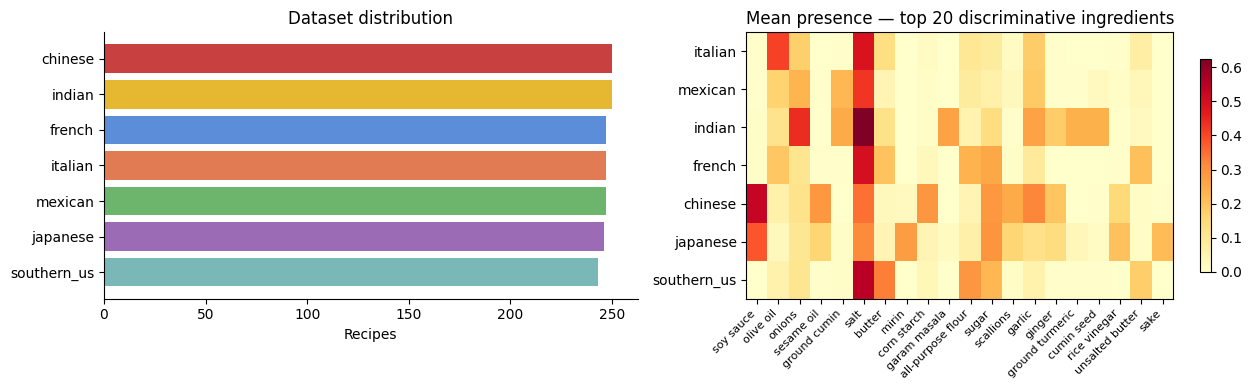

In [3]:
PALETTE = {
    "italian":     "#e07b54",
    "mexican":     "#6db56d",
    "indian":      "#e6b832",
    "french":      "#5b8dd9",
    "chinese":     "#c94040",
    "japanese":    "#9b6bb5",
    "southern_us": "#7ab8b8",
}

counts = df["cuisine"].value_counts()
colors = [PALETTE.get(c, "#aaaaaa") for c in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# -- recipe count by cuisine
axes[0].barh(counts.index[::-1], counts.values[::-1], color=colors[::-1])
axes[0].set_xlabel("Recipes")
axes[0].set_title("Dataset distribution")
axes[0].spines[["top", "right"]].set_visible(False)

# -- mean ingredient presence per cuisine (heatmap)
avg_presence = (
    df.groupby("cuisine")[ingredient_cols]
    .mean()
    .loc[list(PALETTE.keys())]
)
# top 20 most discriminative ingredients (highest cross-cuisine variance)
top20 = avg_presence.std(axis=0).nlargest(20).index
hmap = avg_presence[top20]

im = axes[1].imshow(hmap.values, aspect="auto", cmap="YlOrRd")
axes[1].set_xticks(range(len(top20)))
axes[1].set_xticklabels(top20, rotation=45, ha="right", fontsize=8)
axes[1].set_yticks(range(len(hmap.index)))
axes[1].set_yticklabels(hmap.index)
axes[1].set_title("Mean presence — top 20 discriminative ingredients")
plt.colorbar(im, ax=axes[1], shrink=0.8)

plt.tight_layout()
plt.show()

## Una rete con strato di embedding

Costruiamo ora la rete neurale. La struttura è volutamente minimale: un solo strato nascosto composto da **due soli neuroni**, seguito da uno strato di classificazione.

```
x ∈ {0,1}^V ──► [ Linear V→2 ] ──► ReLU ──► h ∈ ℝ² ──► [ Linear 2→K ] ──► softmax ──► ŷ ∈ ℝ^K
                     W₁, b₁              ↑                    W₂, b₂
                                    embedding
```

Formalmente, la rete calcola due trasformazioni in sequenza:

$$h = \text{ReLU}\bigl(W_1\, x + b_1\bigr) \qquad h \in \mathbb{R}^2$$

$$\hat{y} = \text{softmax}\bigl(W_2\, h + b_2\bigr) \qquad \hat{y} \in \mathbb{R}^K$$

dove $x \in \{0,1\}^V$ è il vettore degli ingredienti ($V = 150$), $K = 7$ è il numero di cucine, e i pesi $W_1 \in \mathbb{R}^{2 \times V}$, $W_2 \in \mathbb{R}^{K \times 2}$ vengono appresi durante l'addestramento.

### Il collo di bottiglia bidimensionale

La scelta di **due soli neuroni nello strato nascosto** è una costrizione geometrica precisa: tutta l'informazione sulla ricetta deve transitare per un piano prima di arrivare alla classificazione. La rete non può "barare" — è costretta a trovare una proiezione in $\mathbb{R}^2$ che preservi le informazioni utili per distinguere le cucine.

Questo piano è lo **spazio di embedding**: dopo l'addestramento, ogni ricetta corrisponde a un punto in questo piano, e ricette simili tenderanno ad occupare posizioni vicine. Prima dell'addestramento, i pesi sono casuali e lo spazio non ha alcuna struttura — è questo il punto di partenza che esaminiamo di seguito.

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# label encoding consistent with PALETTE order
cuisine_order = list(PALETTE.keys())
cuisine_to_idx = {c: i for i, c in enumerate(cuisine_order)}

X = torch.tensor(df[ingredient_cols].values, dtype=torch.float32)
y = torch.tensor(df["cuisine"].map(cuisine_to_idx).values, dtype=torch.long)

vocab_size = X.shape[1]
n_cuisines = len(cuisine_order)

print(f"Input dimension (vocab size): {vocab_size}")
print(f"Output classes:               {n_cuisines}")
print(f"Cuisine → index: {cuisine_to_idx}")

Input dimension (vocab size): 150
Output classes:               7
Cuisine → index: {'italian': 0, 'mexican': 1, 'indian': 2, 'french': 3, 'chinese': 4, 'japanese': 5, 'southern_us': 6}


In [5]:
class CuisineNet(nn.Module):
    def __init__(self, vocab_size, n_cuisines, embed_dim=2):
        super().__init__()
        self.embedding  = nn.Linear(vocab_size, embed_dim)
        self.classifier = nn.Linear(embed_dim, n_cuisines)

    def forward(self, x):
        h = F.relu(self.embedding(x))
        return self.classifier(h)

    def get_embeddings(self, x):
        """Return 2D hidden-layer activations without gradient computation."""
        with torch.no_grad():
            return F.relu(self.embedding(x)).numpy()


torch.manual_seed(42)
model = CuisineNet(vocab_size, n_cuisines, embed_dim=2)

print(model)
print()
for name, p in model.named_parameters():
    print(f"  {name:35s}  shape: {list(p.shape)}")

CuisineNet(
  (embedding): Linear(in_features=150, out_features=2, bias=True)
  (classifier): Linear(in_features=2, out_features=7, bias=True)
)

  embedding.weight                     shape: [2, 150]
  embedding.bias                       shape: [2]
  classifier.weight                    shape: [7, 2]
  classifier.bias                      shape: [7]


### Prima dell'addestramento

Prima di addestrare il modello, osserviamo il suo comportamento con i pesi inizializzati casualmente. Ci aspettiamo due cose:

1. **Predizioni quasi uniformi**: senza aver visto alcun dato, la rete non ha preferenza per nessuna cucina — le probabilità dovrebbero essere vicine a $1/7 \approx 0.14$ per ogni classe.
2. **Spazio di embedding senza struttura**: i punti nel piano 2D saranno distribuiti in modo caotico, senza cluster visibili.

Questo è il punto di partenza. Dopo l'addestramento confronteremo lo stesso spazio e vedremo cosa è cambiato.

In [6]:
# one representative recipe per cuisine (first occurrence in the dataframe)
sample_idx = [df[df["cuisine"] == c].index[0] for c in cuisine_order]

model.eval()
with torch.no_grad():
    probs = F.softmax(model(X[sample_idx]), dim=1).numpy()

# print predicted probability table
col_w = 12
header = f"{'True cuisine':15s}" + "".join(f"{c[:col_w]:>{col_w}s}" for c in cuisine_order)
print(header)
print("─" * len(header))
for true_c, p in zip(cuisine_order, probs):
    row = f"{true_c:15s}" + "".join(f"{v:{col_w}.3f}" for v in p)
    print(row)

True cuisine        italian     mexican      indian      french     chinese    japanese southern_us
───────────────────────────────────────────────────────────────────────────────────────────────────
italian               0.181       0.227       0.102       0.131       0.069       0.098       0.192
mexican               0.181       0.224       0.101       0.131       0.071       0.096       0.196
indian                0.179       0.216       0.100       0.129       0.075       0.093       0.208
french                0.153       0.226       0.097       0.122       0.085       0.089       0.228
chinese               0.168       0.241       0.102       0.129       0.071       0.099       0.191
japanese              0.180       0.221       0.100       0.130       0.073       0.095       0.201
southern_us           0.182       0.227       0.102       0.131       0.069       0.098       0.191


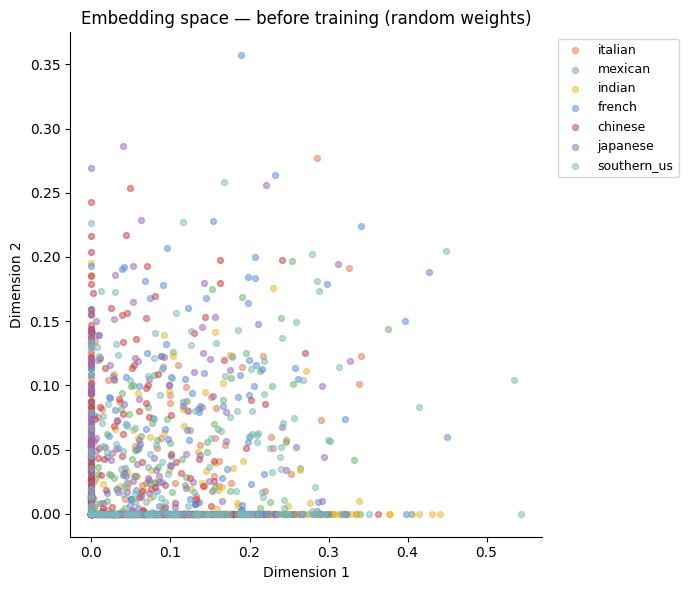

In [7]:
# extract 2D embeddings for all recipes
embeddings = model.get_embeddings(X)  # shape: (N, 2)

fig, ax = plt.subplots(figsize=(7, 6))
for cuisine, color in PALETTE.items():
    mask = (df["cuisine"] == cuisine).values
    ax.scatter(embeddings[mask, 0], embeddings[mask, 1],
               c=color, label=cuisine, alpha=0.5, s=18)

ax.set_title("Embedding space — before training (random weights)")
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Gli ingredienti come vettori

Lo scatter plot qui sopra mostra dove la rete *proietta* ogni ricetta — ma c'è una prospettiva più fondamentale da esplorare. I pesi di $W_1$ non codificano solo una trasformazione: codificano una **rappresentazione di ogni singolo ingrediente**.

Per capire perché, consideriamo cosa succede quando passiamo alla rete il vettore one-hot $x_j$ di un ingrediente isolato — cioè un vettore con 1 in posizione $j$ e 0 altrove:

$$W_1 \, x_j + b_1 \;=\; W_1[:,\, j] + b_1$$

Il risultato è semplicemente la **$j$-esima colonna di $W_1$**, spostata dal bias. Questo significa che ogni colonna di $W_1$ è il vettore bidimensionale che la rete assegna a quell'ingrediente — la sua posizione nello spazio di embedding.

In altri termini: la matrice dei pesi $W_1 \in \mathbb{R}^{2 \times V}$ **è** la matrice degli embedding degli ingredienti. Ogni colonna $\mathbf{e}_j = W_1[:,j] \in \mathbb{R}^2$ è il vettore dell'ingrediente $j$.

Questo ha una conseguenza diretta: possiamo misurare la **somiglianza tra ingredienti** calcolando la similarità coseno tra i loro vettori:

$$\text{sim}(\mathbf{e}_i,\, \mathbf{e}_j) = \frac{\mathbf{e}_i \cdot \mathbf{e}_j}{\|\mathbf{e}_i\| \, \|\mathbf{e}_j\|}$$

Prima dell'addestramento i vettori sono casuali, quindi le somiglianze non avranno senso. Ma la struttura del ragionamento è già tutta qui — e dopo l'addestramento vedremo come questi vettori si riorganizzino per catturare affinità semantiche tra ingredienti.

In [8]:
# W has shape (embed_dim, vocab_size) = (2, 150)
# column j of W is the 2D embedding vector of ingredient j
W = model.embedding.weight.detach().numpy()

print(f"W shape: {W.shape}  →  (embed_dim × vocab_size)")
print(f"Each column = one ingredient's 2D position in the embedding space\n")

# show the embedding vector of a few representative ingredients
probe_ingredients = ["olive oil", "soy sauce", "cumin", "butter", "fish sauce"]
for ing in probe_ingredients:
    if ing in ingredient_cols:
        j   = ingredient_cols.index(ing)
        vec = W[:, j]
        print(f"  {ing:25s}  index {j:3d}  →  [{vec[0]:+.4f},  {vec[1]:+.4f}]")

W shape: (2, 150)  →  (embed_dim × vocab_size)
Each column = one ingredient's 2D position in the embedding space

  olive oil                  index   5  →  [+0.0165,  -0.0599]
  soy sauce                  index   6  →  [-0.0398,  +0.0436]
  cumin                      index 100  →  [-0.0468,  -0.0262]
  butter                     index   9  →  [-0.0599,  -0.0441]


In [9]:
def nearest_ingredients(query, n=5):
    """Return the n most similar ingredients to `query` by cosine similarity."""
    j          = ingredient_cols.index(query)
    query_vec  = W[:, j]
    col_norms  = np.linalg.norm(W, axis=0)                            # (V,)
    query_norm = np.linalg.norm(query_vec)
    cosine_sim = (W.T @ query_vec) / (col_norms * query_norm + 1e-9)  # (V,)

    ranked = np.argsort(cosine_sim)[::-1]
    return [(ingredient_cols[i], cosine_sim[i])
            for i in ranked if ingredient_cols[i] != query][:n]


# before training: results are random — the same function will be called again after training
queries = ["olive oil", "soy sauce", "cumin", "butter", "ginger"]
for ing in queries:
    if ing in ingredient_cols:
        print(f"Nearest to '{ing}':")
        for name, score in nearest_ingredients(ing):
            print(f"    {name:35s}  sim = {score:+.4f}")
        print()

Nearest to 'olive oil':
    buttermilk                           sim = +0.9996
    salsa                                sim = +0.9989
    hoisin sauce                         sim = +0.9982
    potatoes                             sim = +0.9977
    fresh cilantro                       sim = +0.9955

Nearest to 'soy sauce':
    heavy cream                          sim = +1.0000
    fresh lime juice                     sim = +1.0000
    balsamic vinegar                     sim = +1.0000
    corn tortillas                       sim = +0.9999
    chopped onion                        sim = +0.9999

Nearest to 'cumin':
    light soy sauce                      sim = +0.9998
    grated parmesan cheese               sim = +0.9993
    capers                               sim = +0.9991
    shiitake                             sim = +0.9988
    sour cream                           sim = +0.9983

Nearest to 'butter':
    corn starch                          sim = +1.0000
    green onions            

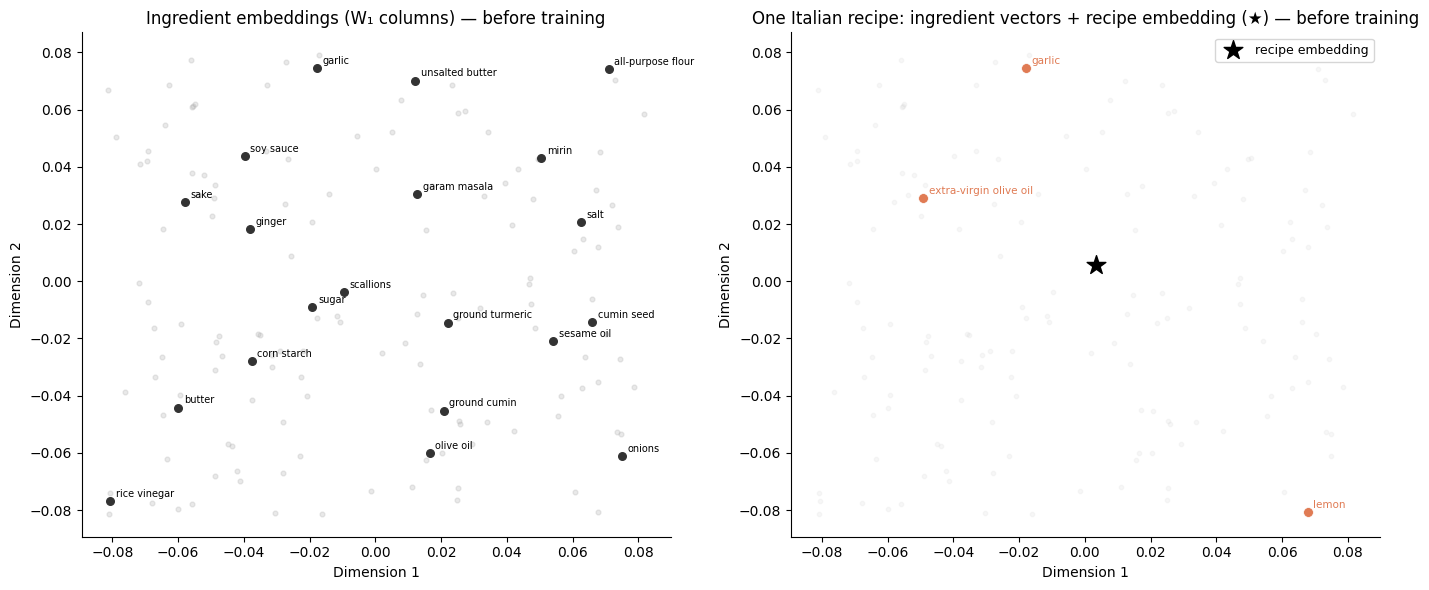

In [10]:
def plot_ingredient_spaces(title_suffix=""):
    """Plot ingredient embedding space and one example recipe — reused before and after training."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # -- left: all ingredient vectors, top-20 discriminative ones labelled
    axes[0].scatter(W[0, :], W[1, :], alpha=0.25, s=12, c="#aaaaaa", zorder=1)
    for ing in top20:
        if ing in ingredient_cols:
            j = ingredient_cols.index(ing)
            axes[0].scatter(W[0, j], W[1, j], c="#333333", s=30, zorder=2)
            axes[0].annotate(ing, (W[0, j], W[1, j]),
                             fontsize=7, xytext=(4, 3), textcoords="offset points")
    axes[0].set_title(f"Ingredient embeddings (W\u2081 columns){title_suffix}")
    axes[0].set_xlabel("Dimension 1")
    axes[0].set_ylabel("Dimension 2")
    axes[0].spines[["top", "right"]].set_visible(False)

    # -- right: one example recipe with its ingredient vectors highlighted
    example_recipe = df[df["cuisine"] == "italian"].iloc[0]
    example_ings   = [c for c in ingredient_cols if example_recipe[c] == 1]

    axes[1].scatter(W[0, :], W[1, :], alpha=0.15, s=10, c="#cccccc", zorder=1)
    for ing in example_ings:
        j = ingredient_cols.index(ing)
        axes[1].scatter(W[0, j], W[1, j],
                        c=PALETTE["italian"], s=50, zorder=3,
                        edgecolors="white", linewidths=0.5)
        axes[1].annotate(ing, (W[0, j], W[1, j]),
                         fontsize=7.5, xytext=(4, 3), textcoords="offset points",
                         color=PALETTE["italian"])
    rec_emb = model.get_embeddings(X[[example_recipe.name]])[0]
    axes[1].scatter(rec_emb[0], rec_emb[1], marker="*", s=200,
                    c="black", zorder=4, label="recipe embedding")
    axes[1].set_title(f"One Italian recipe: ingredient vectors + recipe embedding (\u2605){title_suffix}")
    axes[1].set_xlabel("Dimension 1")
    axes[1].set_ylabel("Dimension 2")
    axes[1].legend(fontsize=9)
    axes[1].spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_ingredient_spaces(title_suffix=" — before training")

## Addestramento

Addestriamo la rete minimizzando la **cross-entropy loss**, che misura quanto le distribuzioni di probabilità predette divergono dalle etichette vere:

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \log \hat{y}_{i,\, c_i}$$

dove $c_i$ è la cucina corretta per la ricetta $i$ e $\hat{y}_{i,c}$ è la probabilità predetta dalla rete per la classe $c$. La loss è alta quando la rete assegna poca probabilità alla risposta giusta, e si avvicina a zero quando la previsione è certa e corretta.

Per aggiornare i pesi utilizziamo **Adam** (Adaptive Moment Estimation), un ottimizzatore che adatta automaticamente il tasso di apprendimento per ciascun parametro in base alla storia dei gradienti — più robusto e veloce del gradiente discendente standard nelle prime fasi dell'apprendimento.

Vale la pena notare che il collo di bottiglia a 2 dimensioni rende il compito oggettivamente difficile: tutta la variabilità di 150 ingredienti deve condensarsi in un piano. L'accuratezza finale sarà inferiore a quella di una rete più larga, ma questo è esattamente il compromesso che vogliamo esplorare — lo spazio guadagnato in interpretabilità vale la perdita in performance.

In [11]:
import torch.optim as optim

LEARNING_RATE = 1e-3
N_EPOCHS      = 300
BATCH_SIZE    = 64

# fresh model with fixed seed for reproducibility
torch.manual_seed(42)
model     = CuisineNet(vocab_size, n_cuisines, embed_dim=2)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

dataset = torch.utils.data.TensorDataset(X, y)
loader  = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True,
                                       generator=torch.Generator().manual_seed(42))

train_losses = []
model.train()
for epoch in range(N_EPOCHS):
    epoch_loss = 0.0
    for xb, yb in loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    train_losses.append(epoch_loss / len(dataset))
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:4d} / {N_EPOCHS}  |  loss = {train_losses[-1]:.4f}")

Epoch   50 / 300  |  loss = 1.1931
Epoch  100 / 300  |  loss = 1.0265
Epoch  150 / 300  |  loss = 0.9553
Epoch  200 / 300  |  loss = 0.9171
Epoch  250 / 300  |  loss = 0.8932
Epoch  300 / 300  |  loss = 0.8797


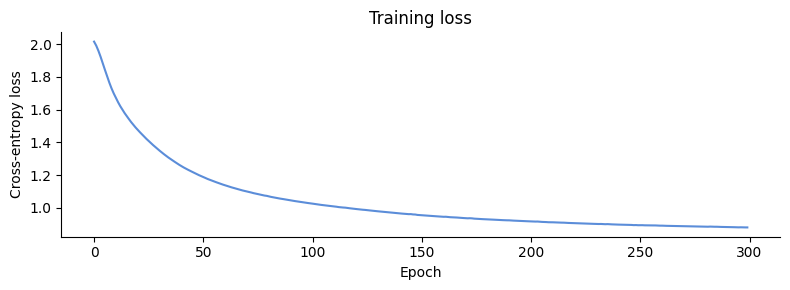

In [12]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(train_losses, color="#5b8dd9", linewidth=1.5)
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Training loss")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Valutazione: matrice di confusione

Per valutare la qualità della classificazione utilizziamo la **matrice di confusione**: una tabella $K \times K$ in cui la cella $(i, j)$ conta quante ricette della cucina $i$ sono state predette come cucina $j$. La diagonale principale raccoglie le predizioni corrette; gli elementi fuori diagonale rivelano le confusioni sistematiche tra cucine.

Le confusioni non sono casuali: ci aspettiamo errori maggiori tra cucine che condividono ingredienti — proprio le coppie che avevamo scelto intenzionalmente (italiana/francese, cinese/giapponese). Questo è già un segnale che lo spazio di embedding ha catturato qualcosa di reale.

Accuracy: 0.695  (69.5%)


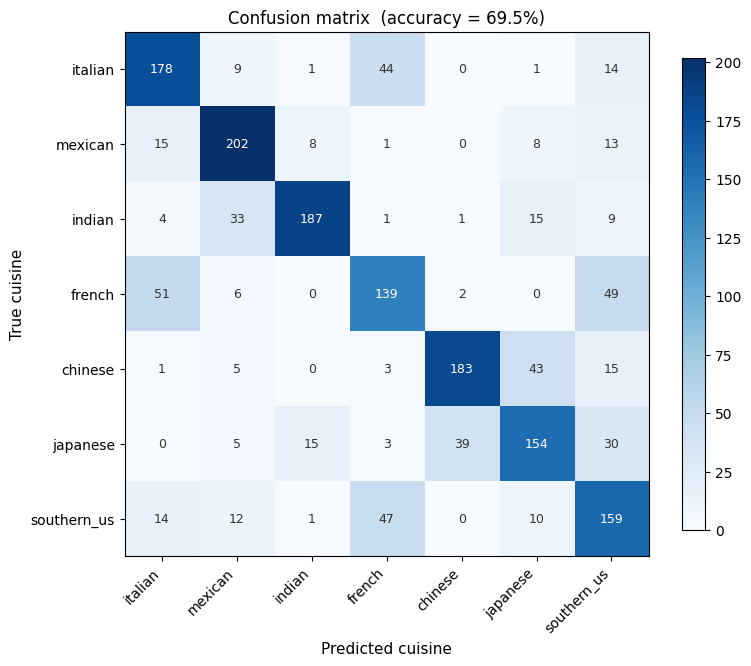

In [13]:
from sklearn.metrics import confusion_matrix, accuracy_score

model.eval()
with torch.no_grad():
    y_pred = model(X).argmax(dim=1).numpy()

y_true = y.numpy()
acc    = accuracy_score(y_true, y_pred)
cm     = confusion_matrix(y_true, y_pred)

print(f"Accuracy: {acc:.3f}  ({acc:.1%})")

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(n_cuisines))
ax.set_yticks(range(n_cuisines))
ax.set_xticklabels(cuisine_order, rotation=45, ha="right", fontsize=10)
ax.set_yticklabels(cuisine_order, fontsize=10)
ax.set_xlabel("Predicted cuisine", fontsize=11)
ax.set_ylabel("True cuisine", fontsize=11)
ax.set_title(f"Confusion matrix  (accuracy = {acc:.1%})", fontsize=12)

# count annotations with contrast-aware text colour
threshold = cm.max() * 0.5
for i in range(n_cuisines):
    for j in range(n_cuisines):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > threshold else "#333333",
                fontsize=9)

plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

## Lo spazio di embedding dopo l'addestramento

Ripetiamo ora esattamente la stessa esplorazione che avevamo fatto prima dell'addestramento. La struttura del codice è identica — ciò che cambia sono i pesi $W_1$, che nel frattempo sono stati ottimizzati per risolvere il compito di classificazione.

Ci aspettiamo di vedere:
- **Cluster di ricette** ben separati per cucina nello scatter plot
- **Ingredienti raggruppati** in zone dello spazio che corrispondono a tradizioni culinarie
- **Nearest neighbor semanticamente coerenti**: gli ingredienti più simili a *olive oil* saranno altri ingredienti mediterranei, quelli vicini a *soy sauce* apparterranno alla tradizione asiatica
- **Cucine simili vicine**: italiana e francese occuperanno regioni adiacenti, così come cinese e giapponese

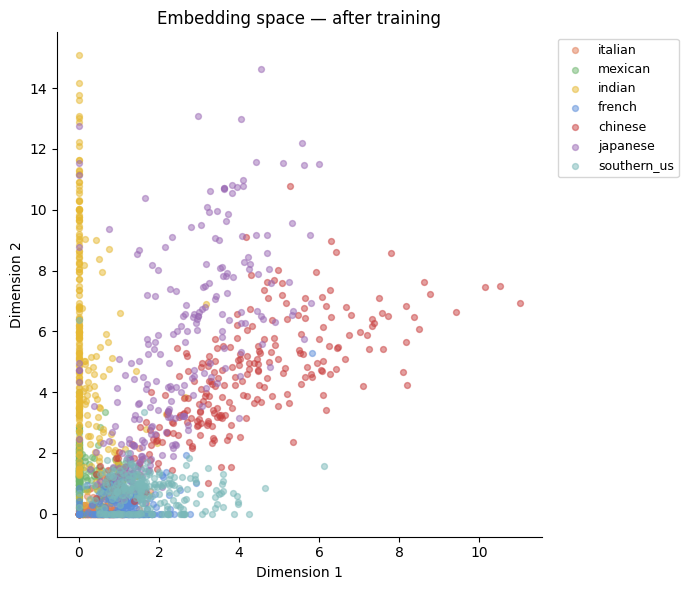

In [14]:
# recipe embeddings after training
embeddings = model.get_embeddings(X)

fig, ax = plt.subplots(figsize=(7, 6))
for cuisine, color in PALETTE.items():
    mask = (df["cuisine"] == cuisine).values
    ax.scatter(embeddings[mask, 0], embeddings[mask, 1],
               c=color, label=cuisine, alpha=0.5, s=18)

ax.set_title("Embedding space — after training")
ax.set_xlabel("Dimension 1")
ax.set_ylabel("Dimension 2")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [15]:
# update W from the trained model
W = model.embedding.weight.detach().numpy()

print(f"W shape: {W.shape}\n")
for ing in probe_ingredients:
    if ing in ingredient_cols:
        j   = ingredient_cols.index(ing)
        vec = W[:, j]
        print(f"  {ing:25s}  index {j:3d}  →  [{vec[0]:+.4f},  {vec[1]:+.4f}]")

W shape: (2, 150)

  olive oil                  index   5  →  [-0.2851,  -0.5266]
  soy sauce                  index   6  →  [+1.4158,  +1.7359]
  cumin                      index 100  →  [-0.0927,  +0.6342]
  butter                     index   9  →  [+0.3697,  -0.0871]


In [16]:
# nearest neighbours after training — now results should reflect culinary affinity
for ing in queries:
    if ing in ingredient_cols:
        print(f"Nearest to '{ing}':")
        for name, score in nearest_ingredients(ing):
            print(f"    {name:35s}  sim = {score:+.4f}")
        print()

Nearest to 'olive oil':
    tomato paste                         sim = +1.0000
    flat leaf parsley                    sim = +0.9988
    sea salt                             sim = +0.9975
    balsamic vinegar                     sim = +0.9941
    extra-virgin olive oil               sim = +0.9941

Nearest to 'soy sauce':
    honey                                sim = +1.0000
    vegetable oil                        sim = +1.0000
    green onions                         sim = +1.0000
    sesame oil                           sim = +0.9999
    scallions                            sim = +0.9998

Nearest to 'cumin':
    ghee                                 sim = +0.9994
    ground cinnamon                      sim = +0.9993
    cilantro leaves                      sim = +0.9980
    white onion                          sim = +0.9954
    garlic paste                         sim = +0.9950

Nearest to 'butter':
    baking soda                          sim = +0.9982
    worcestershire sauce    

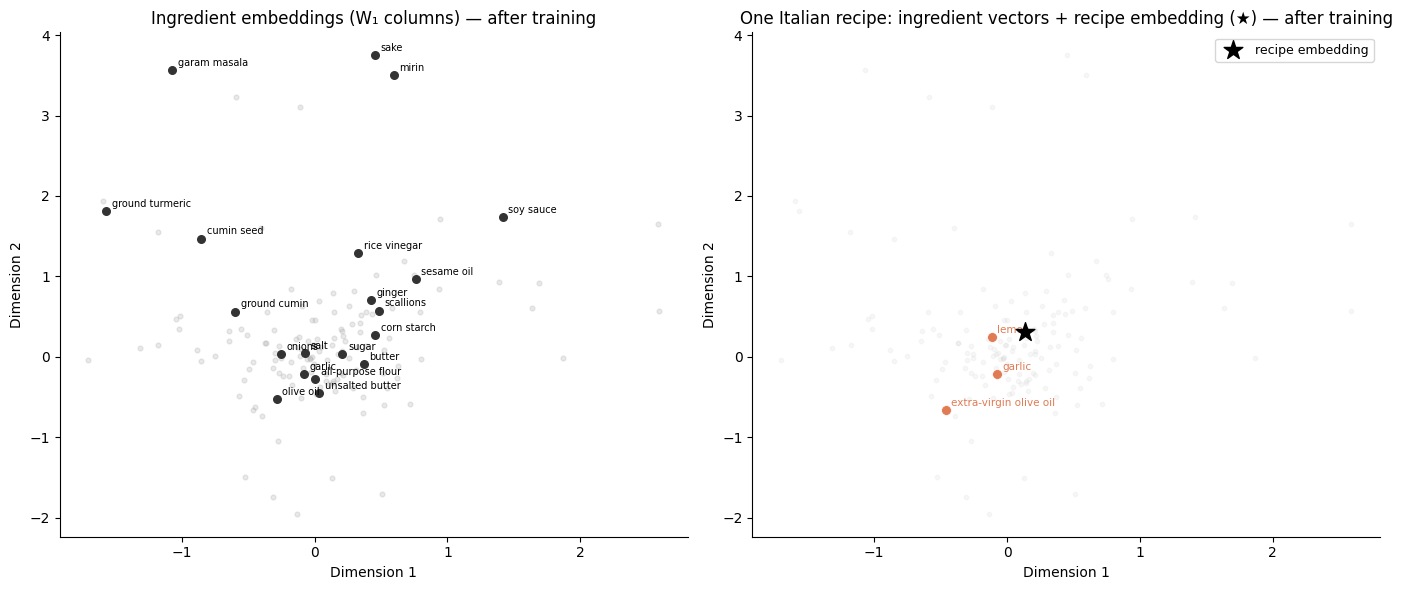

In [17]:
plot_ingredient_spaces(title_suffix=" — after training")

## Esempio 2: Semantica distribuzionale con Word2Vec

Il primo esempio ha mostrato come una rete impari rappresentazioni geometriche degli ingredienti come *effetto collaterale* di un compito supervisionato (classificare la cucina). Ma cosa succede se togliamo le etichette?

Il secondo esempio costruisce embedding **senza supervisione**, usando solo la struttura del dataset: quali ingredienti compaiono insieme nelle ricette.

### Il principio della semantica distribuzionale

L'ipotesi alla base è quella che il linguista J.R. Firth formulò nel 1957:

> *"You shall know a word by the company it keeps."*

Applicata agli ingredienti: **un ingrediente è definito dagli ingredienti con cui tende a comparire**. Due ingredienti sono *simili* non perché co-occorrano direttamente (due ingredienti possono non trovarsi mai nella stessa ricetta e avere comunque rappresentazioni vicine), ma perché tendono ad apparire nello stesso *tipo* di ricette, con gli stessi tipi di ingredienti.

In Word2Vec (Mikolov et al., 2013) questo principio viene trasformato in un compito artificiale: dato un ingrediente *centro*, la rete deve predire quale altro ingrediente della stessa ricetta è il *contesto*. Le due proiezioni — il vettore del centro e quello del contesto — si avvicinano quando l'ingrediente contesto compare spesso nello stesso tipo di ambiente del centro. L'addestramento non avvicina i vettori degli ingredienti che co-occorrono direttamente: avvicina quelli con **distribuzioni contestuali simili su molte ricette diverse**.

In [26]:
# For each recipe, pair each present ingredient (center) with every other present ingredient (context).
# This is the skip-gram objective: predict context from center.

torch.manual_seed(42)

center_list  = []
context_list = []

for recipe_vec in X:
    present = torch.where(recipe_vec > 0)[0].tolist()
    for center in present:
        for context in present:
            if center != context:
                center_list.append(center)
                context_list.append(context)

centers  = torch.tensor(center_list,  dtype=torch.long)
contexts = torch.tensor(context_list, dtype=torch.long)

print(f"Ricette:                     {len(X):>8,}")
print(f"Ingredienti nel vocabolario: {len(ingredient_cols):>8,}")
print(f"Coppie (centro, contesto):   {len(centers):>8,}")
print(f"\nEsempio di coppia:")
print(f"  centro:   {ingredient_cols[centers[0].item()]}")
print(f"  contesto: {ingredient_cols[contexts[0].item()]}")

Ricette:                        1,730
Ingredienti nel vocabolario:      150
Coppie (centro, contesto):     77,318

Esempio di coppia:
  centro:   salt
  contesto: sugar


### L'architettura

La rete ha due layer:

```
indice centro → Embedding(vocab_size × embed_dim) → h → Linear(embed_dim × vocab_size) → logit per ogni ingrediente
```

- **Embedding**: una tabella di lookup — ogni ingrediente ha un vettore di `embed_dim` dimensioni. Questi sono gli embedding che vogliamo imparare.
- **Output**: un layer lineare che proietta l'embedding verso uno score per ciascuno dei 150 ingredienti.
- **Loss**: cross-entropy — dati il centro, vogliamo che lo score del contesto corretto sia il più alto.

Usiamo `embed_dim=8`: abbastanza grande da catturare struttura semantica, abbastanza piccolo da addestrare velocemente. Per visualizzare useremo PCA per ridurre a 2 dimensioni.

In [27]:
class IngredientW2V(nn.Module):
    def __init__(self, vocab_size, embed_dim=8):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.output    = nn.Linear(embed_dim, vocab_size, bias=False)

    def forward(self, center_idx):
        h = self.embedding(center_idx)  # (batch, embed_dim)
        return self.output(h)           # (batch, vocab_size)

    def get_vectors(self):
        """Return the embedding matrix (vocab_size, embed_dim)."""
        return self.embedding.weight.detach().numpy()

torch.manual_seed(42)
w2v = IngredientW2V(vocab_size=len(ingredient_cols), embed_dim=8)
print(w2v)
print(f"\nParametri totali: {sum(p.numel() for p in w2v.parameters()):,}")

IngredientW2V(
  (embedding): Embedding(150, 8)
  (output): Linear(in_features=8, out_features=150, bias=False)
)

Parametri totali: 2,400


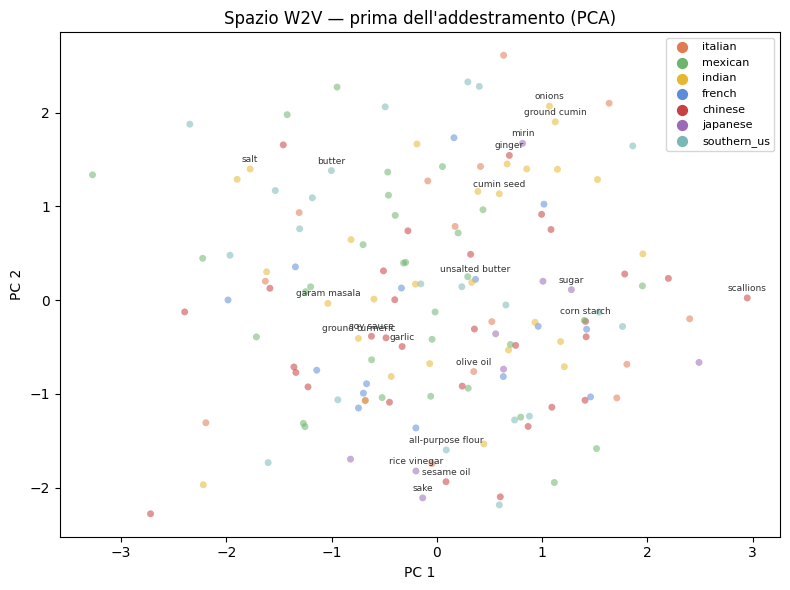

In [28]:
from sklearn.decomposition import PCA

# Color each ingredient by the cuisine where it appears most often
avg_presence      = df.groupby("cuisine")[ingredient_cols].mean()
dominant_cuisine  = avg_presence.idxmax()                          # Series: ingredient → cuisine
ingredient_colors = [PALETTE[dominant_cuisine[ing]] for ing in ingredient_cols]

# Top-20 most discriminative ingredients for labeling
top20_disc = avg_presence.std(axis=0).nlargest(20).index.tolist()

def plot_w2v_space(W, title):
    """Project W to 2D with PCA and scatter-plot ingredients colored by dominant cuisine."""
    coords = PCA(n_components=2).fit_transform(W)   # (vocab_size, 2)
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(coords[:, 0], coords[:, 1], c=ingredient_colors, alpha=0.55, s=25, linewidths=0)
    for ing in top20_disc:
        i = ingredient_cols.index(ing)
        ax.annotate(ing, coords[i], fontsize=6.5, ha="center",
                    xytext=(0, 5), textcoords="offset points", color="#333333")
    for cuisine, color in PALETTE.items():
        ax.scatter([], [], c=color, label=cuisine, s=50)
    ax.legend(fontsize=8, loc="upper right", framealpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2")
    plt.tight_layout(); plt.show()

plot_w2v_space(w2v.get_vectors(), "Spazio W2V — prima dell'addestramento (PCA)")

### Addestramento

Il modello viene addestrato sulle coppie (centro, contesto). Per ogni coppia, la rete vede solo l'indice dell'ingrediente centro e deve produrre uno score alto per l'ingrediente contesto. La loss è cross-entropy: il gradiente spinge l'embedding del centro a essere "utile" per predire i propri contesti.

Poiché ingredienti con *distribuzioni contestuali simili* ricevono gradienti simili da molte ricette diverse, i loro vettori convergono verso regioni simili dello spazio — anche se non si sono mai incontrati nella stessa ricetta.

In [29]:
w2v_criterion = nn.CrossEntropyLoss()
w2v_optimizer = optim.Adam(w2v.parameters(), lr=5e-3)

w2v_dataset = torch.utils.data.TensorDataset(centers, contexts)
w2v_loader  = torch.utils.data.DataLoader(
    w2v_dataset, batch_size=1024, shuffle=True,
    generator=torch.Generator().manual_seed(42)
)

w2v_losses = []
for epoch in range(150):
    epoch_loss = 0.0
    for xb, yb in w2v_loader:
        w2v_optimizer.zero_grad()
        loss = w2v_criterion(w2v(xb), yb)
        loss.backward()
        w2v_optimizer.step()
        epoch_loss += loss.item() * len(xb)
    w2v_losses.append(epoch_loss / len(centers))
    if (epoch + 1) % 30 == 0:
        print(f"Epoch {epoch+1:3d} — loss: {w2v_losses[-1]:.4f}")

Epoch  30 — loss: 4.4193
Epoch  60 — loss: 4.4113
Epoch  90 — loss: 4.4099
Epoch 120 — loss: 4.4092
Epoch 150 — loss: 4.4085


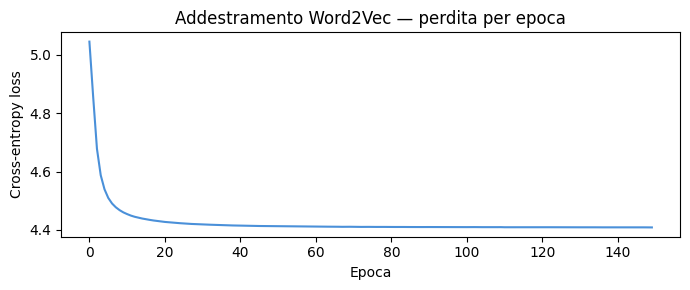

In [30]:
plt.figure(figsize=(7, 3))
plt.plot(w2v_losses, color="#4a90d9", linewidth=1.5)
plt.xlabel("Epoca"); plt.ylabel("Cross-entropy loss")
plt.title("Addestramento Word2Vec — perdita per epoca")
plt.tight_layout(); plt.show()

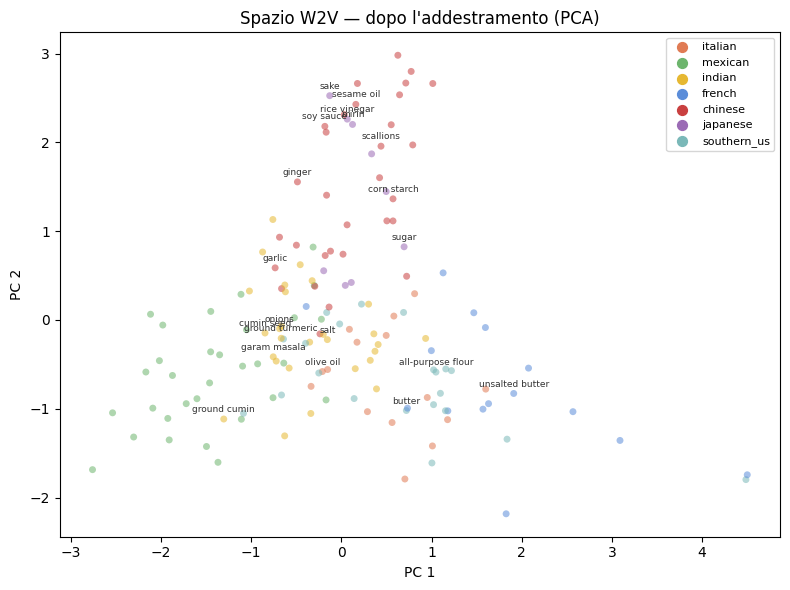

In [31]:
W_trained = w2v.get_vectors()   # (vocab_size, 8)
plot_w2v_space(W_trained, "Spazio W2V — dopo l'addestramento (PCA)")

In [32]:
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

def nearest_w2v(query, W, n=5):
    """Return the n most similar ingredients to query in embedding space W."""
    idx  = ingredient_cols.index(query)
    sims = cos_sim(W[idx:idx+1], W)[0]
    results = []
    for i in sims.argsort()[::-1]:
        if i != idx:
            results.append((ingredient_cols[i], float(sims[i])))
        if len(results) == n:
            break
    return results

probes = ["olive oil", "soy sauce", "cumin", "butter", "ginger"]
for ing in probes:
    if ing in ingredient_cols:
        print(f"\n{ing}:")
        for name, sim in nearest_w2v(ing, W_trained):
            print(f"  {name:<30s}  {sim:.3f}")


olive oil:
  black pepper                    0.955
  fresh parsley                   0.947
  ground black pepper             0.930
  yellow onion                    0.904
  zucchini                        0.903

soy sauce:
  sesame oil                      0.961
  sake                            0.958
  toasted sesame oil              0.954
  rice vinegar                    0.939
  mirin                           0.932

cumin:
  chili powder                    0.954
  cilantro                        0.918
  salsa                           0.893
  corn tortillas                  0.834
  diced tomatoes                  0.823

butter:
  milk                            0.931
  ground cinnamon                 0.904
  heavy cream                     0.895
  egg yolks                       0.885
  ground nutmeg                   0.850

ginger:
  vegetable oil                   0.931
  oil                             0.912
  red chili peppers               0.901
  cilantro leaves             

### Composizionalità: aritmetica vettoriale

Una proprietà notevole degli spazi vettoriali distribuzionali è che le *differenze tra vettori catturano relazioni semantiche*. Se lo spazio ha appreso correttamente la struttura culinaria degli ingredienti, allora operazioni del tipo:

```
v("olive oil") - v("butter") + v("sesame oil") ≈ v(?)
```

dovrebbero restituire un ingrediente che sta a `sesame oil` come `olive oil` sta a `butter`: un grasso da cucina che occupa nello spazio asiatico la stessa posizione che l'olio d'oliva occupa in quello mediterraneo.

Questa è la stessa proprietà che in Word2Vec produce il celebre risultato:

```
v("king") - v("man") + v("woman") ≈ v("queen")
```

La relazione non è codificata esplicitamente: emerge dalla geometria dello spazio appreso.

In [25]:
def analogy(a, b, c, W, n=5):
    """
    Find ingredients x such that  a - b + c ≈ x.
    Reads as: 'a is to b as x is to c'.
    """
    va = W[ingredient_cols.index(a)]
    vb = W[ingredient_cols.index(b)]
    vc = W[ingredient_cols.index(c)]
    target  = va - vb + vc
    sims    = cos_sim(target.reshape(1, -1), W)[0]
    exclude = {a, b, c}
    results = []
    for i in sims.argsort()[::-1]:
        name = ingredient_cols[i]
        if name not in exclude:
            results.append((name, float(sims[i])))
        if len(results) == n:
            break
    return results

def show_analogy(a, b, c, W):
    print(f'"{a}" - "{b}" + "{c}"  →')
    for name, sim in analogy(a, b, c, W, n=5):
        print(f"  {name:<30s}  {sim:.3f}")
    print()

# "olive oil is to butter as ? is to sesame oil"
# (substitute the Mediterranean fat with an Asian one)
if all(ing in ingredient_cols for ing in ["olive oil", "butter", "sesame oil"]):
    show_analogy("olive oil", "butter", "sesame oil", W_trained)

# "soy sauce is to salt as ? is to fish sauce"
if all(ing in ingredient_cols for ing in ["soy sauce", "salt", "fish sauce"]):
    show_analogy("soy sauce", "salt", "fish sauce", W_trained)

# "garlic is to ginger as ? is to onions"
if all(ing in ingredient_cols for ing in ["garlic", "ginger", "onions"]):
    show_analogy("garlic", "ginger", "onions", W_trained)

"olive oil" - "butter" + "sesame oil"  →
  toasted sesame oil              0.924
  rice vinegar                    0.886
  scallions                       0.871
  oyster sauce                    0.857
  soy sauce                       0.849

"garlic" - "ginger" + "onions"  →
  tomato sauce                    0.930
  green bell pepper               0.915
  tomato paste                    0.869
  diced tomatoes                  0.855
  ground beef                     0.837



### Cosa abbiamo imparato

Senza aver mai visto un'etichetta di cucina, il modello ha organizzato gli ingredienti in uno spazio geometrico coerente con la struttura culinaria del dataset. Ingredienti tipicamente mediterranei si raggruppano, così come quelli asiatici, latinoamericani, e così via.

Il meccanismo non è la co-occorrenza diretta: è la **somiglianza di distribuzione contestuale**. Due ingredienti si avvicinano perché appaiono, indipendentemente, negli stessi *tipi* di ricette — con gli stessi compagni. Questo è il principio della semantica distribuzionale, formalizzato da Firth e reso computazionalmente scalabile da Word2Vec.

La proprietà di composizionalità — la possibilità di fare aritmetica semantica — emerge naturalmente da questa struttura: le direzioni nello spazio vettoriale codificano *relazioni* tra ingredienti, e quelle relazioni si combinano linearmente.

Nei moderni modelli del linguaggio (BERT, GPT e i loro successori), lo stesso principio opera su scala massiva: miliardi di coppie (token, contesto) estratte da enormi corpora. La geometria risultante è di dimensioni molto più grandi (centinaia o migliaia di dimensioni), ma la logica è identica — e le rappresentazioni che emergono sono alla base di tutto il ragionamento linguistico di cui questi modelli sono capaci.